In [44]:
%pip install pandas plotly matplotlib seaborn scikit-learn nbformat

Note: you may need to restart the kernel to use updated packages.


In [45]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt

In [46]:
url = "https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset/resolve/main/dataset.csv"

df = pd.read_csv(url, index_col=0)
print(df.shape)
 

(114000, 20)


In [47]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [48]:
df.to_csv("data/spotify_original.csv")

In [49]:
df.isna().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [50]:
df = df.dropna()
print(df.shape)

(113999, 20)


In [51]:
print(df["track_genre"].nunique())

114


In [52]:
generos = ["classical", "edm", "heavy-metal", "jazz", "reggaeton"]

df = df[df["track_genre"].isin(generos)]
print(df.shape)

(5000, 20)


In [53]:
print(df["track_id"].duplicated().sum())

87


In [54]:
df = df.drop_duplicates(subset="track_id", keep=False)
print(df.shape)

(4826, 20)


In [55]:
df[df["track_name"] == "MIA"]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
89018,5hnGly9RuGiixupoVrLTNI,Bad Bunny;Drake,New Pop Icons,MIA,0,210367,False,0.817,0.539,6,-6.349,0,0.0621,0.0141,0.000496,0.099,0.158,97.061,4,reggaeton
89022,0tQyUsejipsHr5BEdx7wLX,Bad Bunny;Drake,Today's Party Hits,MIA,0,210367,False,0.817,0.539,6,-6.349,0,0.0621,0.0141,0.000496,0.099,0.158,97.061,4,reggaeton
89804,3gE4eQH3K83Sght0ZLvuBK,Bad Bunny;Drake,X 100PRE,MIA,64,210367,False,0.816,0.538,6,-6.354,0,0.0617,0.0142,0.000496,0.099,0.156,97.054,4,reggaeton


In [56]:
print(df.duplicated(subset=["track_name", "artists"]).sum())

1342


In [57]:
df = df.drop_duplicates(subset=["track_name", "artists"])
print(df.shape)

(3484, 20)


In [58]:
df = df.drop_duplicates(subset=["track_name", "artists"])
print(df.shape)

(3484, 20)


In [59]:
df[["tempo", "loudness", "duration_ms"]].describe()

,tempo,loudness,duration_ms
count,3484.000000,3484.000000,3.484000e+03
mean,119.211258,-9.412884,2.286654e+05
std,30.167402,7.275951,1.303181e+05
min,0.000000,-41.531000,1.745300e+04
25%,95.982000,-11.635000,1.731882e+05
50%,118.039000,-6.430500,2.097595e+05
75%,137.603750,-4.569500,2.569930e+05
max,214.024000,0.366000,2.646866e+06


In [60]:
df = df[df["tempo"] > 0]

df = df[df["duration_ms"] < 600000]

print(df.shape)

(3443, 20)


In [61]:
df["track_genre"].value_counts()

track_genre
heavy-metal    984
classical      723
edm            672
reggaeton      596
jazz           468
Name: count, dtype: int64

In [62]:
df.to_csv("data/canciones.csv", index=False)

In [63]:
colores = {
    "classical": "#F2C14E",
    "edm": "#4CC9F0",
    "heavy-metal": "#F25C54",
    "jazz": "#B388EB",
    "reggaeton": "#1ED760",
}

In [64]:
# Energía de cada género: cada caja resume cientos de canciones
fig = px.box(df, x="track_genre", y="energy", color="track_genre", color_discrete_map=colores)
fig.show()

In [65]:
# Cada punto es una canción. hover_name -> al pasar el ratón sale el título
fig = px.scatter(df, x="energy", y="acousticness", color="track_genre",
                 color_discrete_map=colores, hover_name="track_name", opacity=0.6)
fig.show()

In [66]:
# Columnas para el radar (todas van de 0 a 1)
columnas_radar = ["danceability", "energy", "speechiness", "acousticness", "instrumentalness", "valence"]

# Media de cada columna para cada género
medias = df.groupby("track_genre")[columnas_radar].mean()
medias

,danceability,energy,speechiness,acousticness,instrumentalness,valence
track_genre,,,,,,
classical,0.379393,0.200085,0.050768,0.911534,0.600195,0.374654
edm,0.648223,0.749659,0.073012,0.119810,0.050860,0.453035
heavy-metal,0.430012,0.874231,0.074288,0.015104,0.082770,0.388917
jazz,0.531271,0.371069,0.055398,0.668782,0.128053,0.453251
reggaeton,0.757076,0.731950,0.120849,0.167289,0.003641,0.647806


In [67]:
import plotly.graph_objects as go

# Un gráfico vacío
fig = go.Figure()

# Añadimos una "telaraña" por cada género
for genero in generos:
    fig.add_trace(go.Scatterpolar(r=medias.loc[genero], theta=columnas_radar,
                                  fill="toself", name=genero, line_color=colores[genero]))

fig.show()

In [68]:
# Tres columnas a la vez: se puede girar con el ratón
fig = px.scatter_3d(df, x="energy", y="acousticness", z="danceability",
                    color="track_genre", color_discrete_map=colores,
                    hover_name="track_name", opacity=0.7)

# Puntos más pequeños para que se vea mejor
fig.update_traces(marker_size=3)
fig.show()

In [69]:
columnas_modelo = ["danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo", "duration_ms"]

X = df[columnas_modelo]

y = df["track_genre"]

In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
    )


print(X_train.shape, X_test.shape)    

(2754, 10) (689, 10)


In [71]:
y_test.value_counts(normalize=True)

track_genre
heavy-metal    0.285922
classical      0.210450
edm            0.194485
reggaeton      0.172714
jazz           0.136430
Name: proportion, dtype: float64

In [72]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, pred_knn)

print(f"Accuracy of KNN: ", acc_knn)
 

Accuracy of KNN:  0.3265602322206096


In [73]:
fig = px.box(X_train)
fig.show()

In [74]:
from sklearn.preprocessing import StandardScaler

escalador = StandardScaler()

escalador.fit(X_train)

X_train_esc = escalador.transform(X_train)
X_test_esc = escalador.transform(X_test)

X_train_esc = pd.DataFrame(X_train_esc, columns=columnas_modelo)
X_test_esc = pd.DataFrame(X_test_esc, columns=columnas_modelo)
 

In [75]:
fig = px.box(X_train_esc)
fig.show()

In [76]:
knn_esc = KNeighborsClassifier(n_neighbors=5)
knn_esc.fit(X_train_esc, y_train)

pred_knn_esc = knn_esc.predict(X_test_esc)

acc_knn_esc = accuracy_score(y_test, pred_knn_esc)
print(f"Accuracy of KNN with scaled data: ", acc_knn_esc)

Accuracy of KNN with scaled data:  0.795355587808418


In [77]:
from sklearn.linear_model import LogisticRegression

# max_iter=1000 -> le damos más intentos para aprender (si no, a veces avisa)
logistica = LogisticRegression(max_iter=1000)

# La logística también necesita datos normalizados
logistica.fit(X_train_esc, y_train)

pred_log = logistica.predict(X_test_esc)

acc_log = accuracy_score(y_test, pred_log)
print("Accuracy regresión logística:", acc_log)

Accuracy regresión logística: 0.7793904208998549


In [78]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# max_depth=3 -> solo 3 niveles de preguntas (para poder leerlo)
arbol = DecisionTreeClassifier(max_depth=3, random_state=42)

# Al árbol le damos los datos SIN normalizar: no le hace falta
arbol.fit(X_train, y_train)

pred_arbol = arbol.predict(X_test)

acc_arbol = accuracy_score(y_test, pred_arbol)
print("Accuracy árbol:", acc_arbol)

Accuracy árbol: 0.7387518142235123


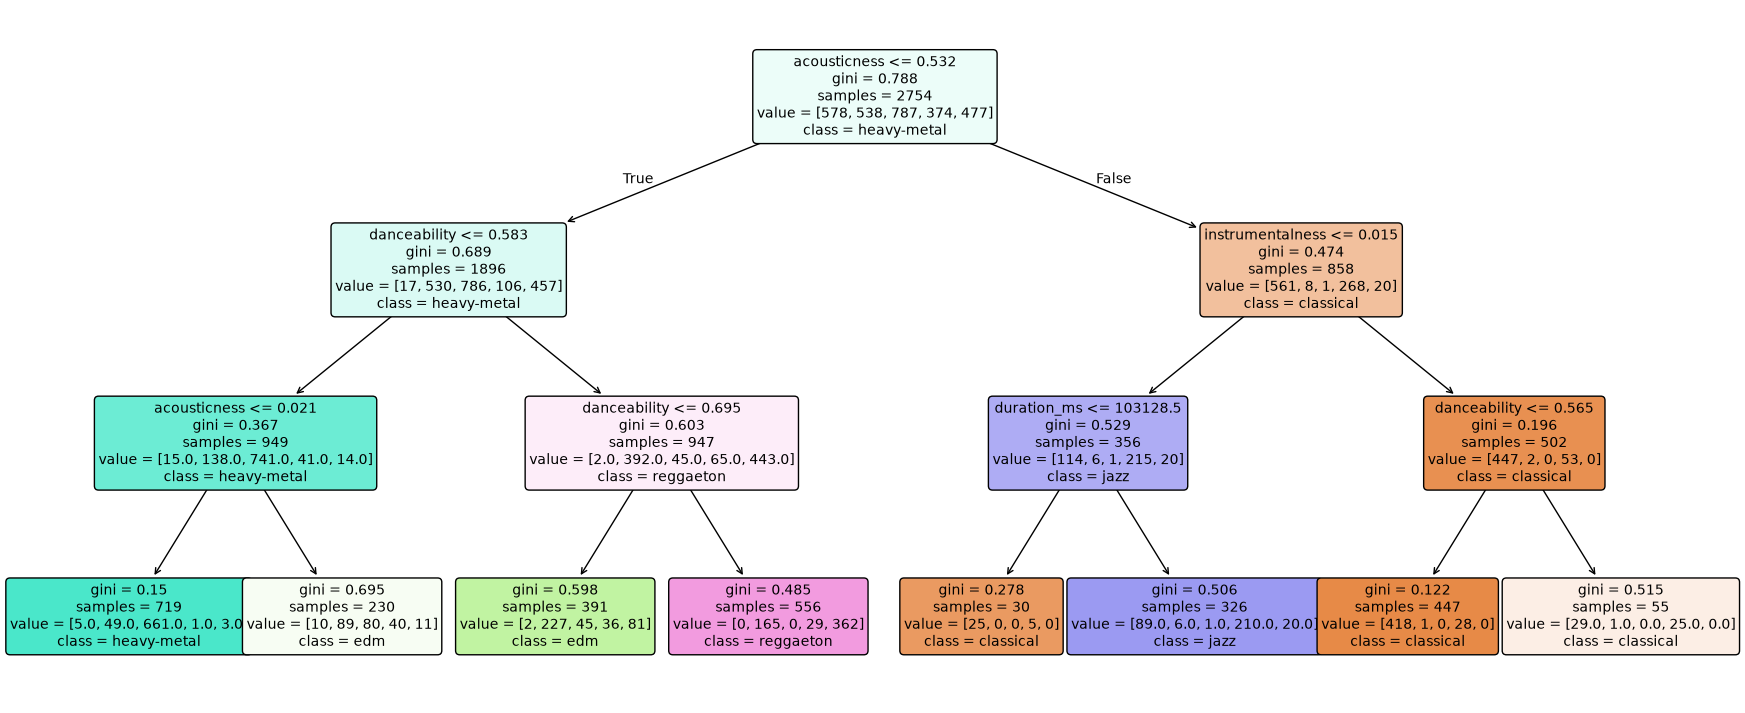

In [79]:
# Dibujamos el árbol
plt.figure(figsize=(22, 9))
plot_tree(arbol, feature_names=columnas_modelo, class_names=arbol.classes_,
          filled=True, rounded=True, fontsize=10)
plt.show()

In [80]:
from sklearn.ensemble import RandomForestClassifier

# 100 árboles
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Tampoco necesita normalizar (son árboles)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)
print("Accuracy Random Forest:", acc_rf)

Accuracy Random Forest: 0.8621190130624092


In [81]:
# Tabla con los resultados de todos los modelos
resultados = pd.DataFrame({
    "modelo": ["KNN sin normalizar", "KNN normalizado", "Regresión logística", "Árbol (3 niveles)", "Random Forest"],
    "accuracy": [acc_knn, acc_knn_esc, acc_log, acc_arbol, acc_rf],
})
resultados

,modelo,accuracy
0,KNN sin normalizar,0.326560
1,KNN normalizado,0.795356
2,Regresión logística,0.779390
3,Árbol (3 niveles),0.738752
4,Random Forest,0.862119


In [82]:
# text_auto=".2f" -> escribe el número encima de cada barra con 2 decimales
fig = px.bar(resultados, x="modelo", y="accuracy", color="modelo", text_auto=".2f")
fig.show()

In [83]:
# Importancia de cada columna para el Random Forest
importancias = pd.DataFrame({
    "columna": columnas_modelo,
    "importancia": rf.feature_importances_,
})

# Ordenamos de menor a mayor para que el gráfico quede bonito
importancias = importancias.sort_values("importancia")

fig = px.bar(importancias, x="importancia", y="columna", orientation="h")
fig.show()

In [84]:
import joblib

# Guardamos el Random Forest en un fichero
joblib.dump(rf, "modelos/modelo_generos.pkl")

['modelos/modelo_generos.pkl']

In [85]:
# Lo cargamos como lo hará la app, y probamos que funciona
modelo = joblib.load("modelos/modelo_generos.pkl")

# Una canción conocida
cancion = df[df["track_name"] == "The Nights"]
cancion

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
30010,0ct6r3EGTcMLPtrXHDvVjc,Avicii,The Days / Nights,The Nights,86,176658,False,0.527,0.835,6,-5.298,1,0.0433,0.0166,0.0,0.249,0.654,125.983,4,edm


In [86]:
print(modelo.predict(cancion[columnas_modelo]))

['edm']
